# Evaluate BED

Evaluate aline on BED tasks

In [43]:
import torch

import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl


import random
import os
import sys
from hydra import initialize, compose
from hydra.utils import instantiate
from omegaconf import OmegaConf

# Add the project root to the Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)


from utils import set_seed, load_state_dict
from utils.eval import eval_boed

from utils import create_target_mask, select_targets_by_mask, compute_ll

from model import Aline

COLORS = ['#0072B2', '#009E73', '#D55E00', '#CC79A7', '#F0E442', '#56B4E9']
plt.style.use(['seaborn-v0_8-colorblind'])

In [44]:
def load(config_overrides=[], state_dict=None, config_name="train_bed", verbose=False):
    # Initialise the hyper params
    with initialize(version_base=None, config_path="../config"):
        cfg = compose(config_name=config_name, overrides=config_overrides)
        
    if verbose:
        print(OmegaConf.to_yaml(cfg))


    # Setting device
    if not torch.cuda.is_available():
        cfg.device = "cpu"
    torch.set_default_device(cfg.device)
    if cfg.device == "cuda":
        torch.set_default_dtype(torch.float32)
        torch.set_default_device("cuda")

    # Setting random seed
    if cfg.fix_seed:
        set_seed(cfg.seed)
    else:
        cfg.seed = torch.random.seed()

    # Data
    experiment = instantiate(cfg.task)

    # Model
    embedder = instantiate(cfg.embedder)
    encoder = instantiate(cfg.encoder)
    head = instantiate(cfg.head)
    model = Aline(embedder, encoder, head)
    

    if state_dict is not None:
        model = load_state_dict(model, "." + cfg.output_dir, state_dict)


    return cfg, experiment, model

## Location Finding

### EIG Bounds

In [33]:
n_query = 2000

cfg, experiment, model = load([f"task.n_query_init={n_query}"], "checkpoints/aae_Location_d2_1_epoch_20000.pth")

#bounds = eval_boed(model, experiment, cfg.T-1, int(1e3), 2000, 40, cfg.time_token)
bounds = eval_boed(model, experiment, cfg.T-1, 50000, 500, 10, cfg.time_token)
bounds

Step 0: PCE 5.495816230773926, NMC 5.527988910675049
Step 1: PCE 5.61026668548584, NMC 5.698141574859619
Step 2: PCE 5.689311504364014, NMC 5.706240653991699
Step 3: PCE 4.699003219604492, NMC 4.703656196594238
Step 4: PCE 4.693667411804199, NMC 4.706839084625244
Step 5: PCE 5.759934425354004, NMC 5.781342506408691
Step 6: PCE 5.17171573638916, NMC 5.182333946228027
Step 7: PCE 5.316436767578125, NMC 5.33044958114624
Step 8: PCE 5.368129730224609, NMC 5.379103183746338
Step 9: PCE 5.296477794647217, NMC 5.437963962554932
Step 10: PCE 5.286187171936035, NMC 5.291886329650879
Step 11: PCE 4.234240531921387, NMC 4.236508846282959
Step 12: PCE 5.703189849853516, NMC 5.996864318847656
Step 13: PCE 5.7718825340271, NMC 5.948295593261719
Step 14: PCE 5.249512195587158, NMC 5.2998881340026855
Step 15: PCE 6.022841930389404, NMC 6.12246561050415
Step 16: PCE 6.335949420928955, NMC 6.3506011962890625
Step 17: PCE 4.123688697814941, NMC 4.126877307891846
Step 18: PCE 5.6962761878967285, NMC 5.721

AttrDict({'pce_mean': tensor(5.4648), 'pce_err': tensor(0.0860), 'nmc_mean': tensor(5.5386), 'nmc_err': tensor(0.0949)})

In [36]:
n_query = 1000

cfg, experiment, model = load([f"task.n_query_init={n_query}"], "checkpoints/aae_Location_d2_1_epoch_30000.pth")

#bounds = eval_boed(model, experiment, cfg.T-1, int(1e3), 2000, 40, cfg.time_token)
bounds = eval_boed(model, experiment, cfg.T-1, 5000000, 500, 20, cfg.time_token)
bounds

Step 0: PCE 14.383268356323242, NMC 15.56157398223877
Step 1: PCE 14.089303970336914, NMC 14.955945014953613
Step 2: PCE 13.997278213500977, NMC 15.16172981262207
Step 3: PCE 14.210126876831055, NMC 15.110933303833008
Step 4: PCE 14.147540092468262, NMC 14.892110824584961
Step 5: PCE 13.929516792297363, NMC 14.818443298339844
Step 6: PCE 14.017184257507324, NMC 14.705345153808594
Step 7: PCE 14.608322143554688, NMC 16.28615379333496
Step 8: PCE 14.195085525512695, NMC 15.413793563842773
Step 9: PCE 14.176396369934082, NMC 15.4527006149292
Step 10: PCE 14.042741775512695, NMC 15.193727493286133
Step 11: PCE 14.283378601074219, NMC 15.362088203430176
Step 12: PCE 14.388201713562012, NMC 15.490808486938477
Step 13: PCE 14.500988960266113, NMC 15.820302963256836
Step 14: PCE 14.01823902130127, NMC 14.983541488647461
Step 15: PCE 13.974865913391113, NMC 15.268963813781738
Step 16: PCE 14.661718368530273, NMC 15.852450370788574
Step 17: PCE 13.890707015991211, NMC 15.035799980163574
Step 18:

AttrDict({'pce_mean': tensor(14.1687), 'pce_err': tensor(0.0596), 'nmc_mean': tensor(15.2236), 'nmc_err': tensor(0.1043)})

In [37]:
n_query = 1000

cfg, experiment, model = load([f"task.n_query_init={n_query}"], "checkpoints/aae_Location_d2_1_epoch_40000.pth")

#bounds = eval_boed(model, experiment, cfg.T-1, int(1e3), 2000, 40, cfg.time_token)
bounds = eval_boed(model, experiment, cfg.T-1, 5000000, 500, 20, cfg.time_token)
bounds

Step 0: PCE 14.39228630065918, NMC 15.605813980102539
Step 1: PCE 14.191980361938477, NMC 15.911056518554688
Step 2: PCE 13.79851245880127, NMC 14.99206256866455
Step 3: PCE 14.353477478027344, NMC 15.367334365844727
Step 4: PCE 14.280427932739258, NMC 15.065223693847656
Step 5: PCE 14.13368034362793, NMC 15.118062973022461
Step 6: PCE 13.748562812805176, NMC 14.370222091674805
Step 7: PCE 14.741811752319336, NMC 16.392292022705078
Step 8: PCE 14.11308479309082, NMC 15.050768852233887
Step 9: PCE 14.403674125671387, NMC 15.81109619140625
Step 10: PCE 13.789050102233887, NMC 14.52778148651123
Step 11: PCE 14.548591613769531, NMC 16.194116592407227
Step 12: PCE 14.354496955871582, NMC 15.419073104858398
Step 13: PCE 14.313032150268555, NMC 15.283334732055664
Step 14: PCE 14.114779472351074, NMC 15.354711532592773
Step 15: PCE 14.512110710144043, NMC 16.16649055480957
Step 16: PCE 14.856195449829102, NMC 16.415267944335938
Step 17: PCE 14.485692024230957, NMC 15.464620590209961
Step 18: P

AttrDict({'pce_mean': tensor(14.2263), 'pce_err': tensor(0.0580), 'nmc_mean': tensor(15.3351), 'nmc_err': tensor(0.1042)})

In [38]:
n_query = 1000

cfg, experiment, model = load([f"task.n_query_init={n_query}"], "checkpoints/aae_Location_d2_1_epoch_50000.pth")

#bounds = eval_boed(model, experiment, cfg.T-1, int(1e3), 2000, 40, cfg.time_token)
bounds = eval_boed(model, experiment, cfg.T-1, 5000000, 500, 20, cfg.time_token)
bounds

Step 0: PCE 14.561101913452148, NMC 15.79400634765625
Step 1: PCE 14.643302917480469, NMC 16.503433227539062
Step 2: PCE 14.041964530944824, NMC 15.35746955871582
Step 3: PCE 14.417684555053711, NMC 15.332067489624023
Step 4: PCE 14.619526863098145, NMC 15.915919303894043
Step 5: PCE 14.644134521484375, NMC 15.901849746704102
Step 6: PCE 14.267560005187988, NMC 15.14635944366455
Step 7: PCE 14.916803359985352, NMC 16.99613380432129
Step 8: PCE 14.260629653930664, NMC 15.495597839355469
Step 9: PCE 14.586064338684082, NMC 16.32990264892578
Step 10: PCE 14.281344413757324, NMC 15.481145858764648
Step 11: PCE 14.42236328125, NMC 15.959858894348145
Step 12: PCE 14.361844062805176, NMC 15.987548828125
Step 13: PCE 14.388242721557617, NMC 15.598630905151367
Step 14: PCE 14.413165092468262, NMC 15.767003059387207
Step 15: PCE 14.644999504089355, NMC 16.73687171936035
Step 16: PCE 14.820055961608887, NMC 16.680173873901367
Step 17: PCE 14.3360595703125, NMC 15.677129745483398
Step 18: PCE 14.3

AttrDict({'pce_mean': tensor(14.4655), 'pce_err': tensor(0.0504), 'nmc_mean': tensor(15.8498), 'nmc_err': tensor(0.1057)})

In [39]:
n_query = 1000

cfg, experiment, model = load([f"task.n_query_init={n_query}"], "checkpoints/aae_Location_d2_1_epoch_60000.pth")

#bounds = eval_boed(model, experiment, cfg.T-1, int(1e3), 2000, 40, cfg.time_token)
bounds = eval_boed(model, experiment, cfg.T-1, 5000000, 500, 20, cfg.time_token)
bounds

Step 0: PCE 14.883099555969238, NMC 16.330299377441406
Step 1: PCE 14.653535842895508, NMC 16.595226287841797
Step 2: PCE 14.376510620117188, NMC 16.031999588012695
Step 3: PCE 14.393200874328613, NMC 15.712160110473633
Step 4: PCE 14.492901802062988, NMC 15.963101387023926
Step 5: PCE 14.433618545532227, NMC 15.756185531616211
Step 6: PCE 13.997111320495605, NMC 14.818031311035156
Step 7: PCE 14.908851623535156, NMC 16.93662452697754
Step 8: PCE 14.490328788757324, NMC 15.673685073852539
Step 9: PCE 14.652589797973633, NMC 16.315662384033203
Step 10: PCE 14.467512130737305, NMC 15.635934829711914
Step 11: PCE 14.47654914855957, NMC 16.33974266052246
Step 12: PCE 14.313325881958008, NMC 15.836751937866211
Step 13: PCE 14.590726852416992, NMC 16.041622161865234
Step 14: PCE 14.714105606079102, NMC 16.349414825439453
Step 15: PCE 14.580612182617188, NMC 16.708894729614258
Step 16: PCE 14.866159439086914, NMC 16.446073532104492
Step 17: PCE 14.760775566101074, NMC 16.294584274291992
Step 

AttrDict({'pce_mean': tensor(14.5112), 'pce_err': tensor(0.0507), 'nmc_mean': tensor(15.9462), 'nmc_err': tensor(0.1046)})

In [40]:
n_query = 1000

cfg, experiment, model = load([f"task.n_query_init={n_query}"], "checkpoints/aae_Location_d2_1_epoch_70000.pth")

#bounds = eval_boed(model, experiment, cfg.T-1, int(1e3), 2000, 40, cfg.time_token)
bounds = eval_boed(model, experiment, cfg.T-1, 5000000, 500, 20, cfg.time_token)
bounds

Step 0: PCE 14.456611633300781, NMC 15.692400932312012
Step 1: PCE 14.566686630249023, NMC 16.624731063842773
Step 2: PCE 14.126489639282227, NMC 15.824551582336426
Step 3: PCE 14.503114700317383, NMC 16.0092716217041
Step 4: PCE 14.430598258972168, NMC 15.611544609069824
Step 5: PCE 14.3075590133667, NMC 15.404073715209961
Step 6: PCE 14.249032974243164, NMC 15.1201171875
Step 7: PCE 14.37975788116455, NMC 15.945398330688477
Step 8: PCE 14.357501029968262, NMC 15.80250358581543
Step 9: PCE 14.669685363769531, NMC 16.610919952392578
Step 10: PCE 14.585245132446289, NMC 15.940821647644043
Step 11: PCE 14.551831245422363, NMC 16.233074188232422
Step 12: PCE 14.473012924194336, NMC 15.769052505493164
Step 13: PCE 14.537576675415039, NMC 15.933850288391113
Step 14: PCE 14.759831428527832, NMC 16.46343231201172
Step 15: PCE 14.496393203735352, NMC 16.43231773376465
Step 16: PCE 14.86156177520752, NMC 16.744787216186523
Step 17: PCE 14.630099296569824, NMC 15.691474914550781
Step 18: PCE 14.

AttrDict({'pce_mean': tensor(14.4661), 'pce_err': tensor(0.0525), 'nmc_mean': tensor(15.9014), 'nmc_err': tensor(0.1100)})

In [41]:
n_query = 1000

cfg, experiment, model = load([f"task.n_query_init={n_query}"], "checkpoints/aae_Location_d2_1_epoch_80000.pth")

#bounds = eval_boed(model, experiment, cfg.T-1, int(1e3), 2000, 40, cfg.time_token)
bounds = eval_boed(model, experiment, cfg.T-1, 5000000, 500, 20, cfg.time_token)
bounds

Step 0: PCE 14.807212829589844, NMC 16.09290885925293
Step 1: PCE 14.624371528625488, NMC 16.221569061279297
Step 2: PCE 13.485132217407227, NMC 14.911722183227539
Step 3: PCE 14.682052612304688, NMC 15.997146606445312
Step 4: PCE 14.706575393676758, NMC 16.067481994628906
Step 5: PCE 14.640974044799805, NMC 15.983457565307617
Step 6: PCE 14.318880081176758, NMC 15.256604194641113
Step 7: PCE 14.841028213500977, NMC 17.023366928100586
Step 8: PCE 14.63050651550293, NMC 16.164379119873047
Step 9: PCE 14.697961807250977, NMC 16.4835262298584
Step 10: PCE 14.457964897155762, NMC 15.833292007446289
Step 11: PCE 14.799148559570312, NMC 16.927324295043945
Step 12: PCE 14.173588752746582, NMC 15.74573040008545
Step 13: PCE 14.5867919921875, NMC 16.186948776245117
Step 14: PCE 14.211019515991211, NMC 15.573023796081543
Step 15: PCE 14.68499755859375, NMC 16.590286254882812
Step 16: PCE 14.823946952819824, NMC 16.373262405395508
Step 17: PCE 14.771707534790039, NMC 16.371601104736328
Step 18: P

AttrDict({'pce_mean': tensor(14.4870), 'pce_err': tensor(0.0535), 'nmc_mean': tensor(15.9424), 'nmc_err': tensor(0.1090)})

In [42]:
n_query = 1000

cfg, experiment, model = load([f"task.n_query_init={n_query}"], "checkpoints/aae_Location_d2_1_epoch_90000.pth")

#bounds = eval_boed(model, experiment, cfg.T-1, int(1e3), 2000, 40, cfg.time_token)
bounds = eval_boed(model, experiment, cfg.T-1, 5000000, 500, 20, cfg.time_token)
bounds

Step 0: PCE 14.750625610351562, NMC 16.199016571044922
Step 1: PCE 14.697758674621582, NMC 16.971454620361328
Step 2: PCE 14.138148307800293, NMC 15.440960884094238
Step 3: PCE 14.392913818359375, NMC 15.462873458862305
Step 4: PCE 14.612634658813477, NMC 15.966751098632812
Step 5: PCE 14.700117111206055, NMC 16.147829055786133
Step 6: PCE 14.280515670776367, NMC 15.160067558288574
Step 7: PCE 14.858505249023438, NMC 16.88303565979004
Step 8: PCE 14.720457077026367, NMC 16.302165985107422
Step 9: PCE 14.684331893920898, NMC 16.540180206298828
Step 10: PCE 14.48718547821045, NMC 15.807891845703125
Step 11: PCE 14.675012588500977, NMC 16.65326690673828
Step 12: PCE 14.440912246704102, NMC 15.908506393432617
Step 13: PCE 14.584933280944824, NMC 16.009510040283203
Step 14: PCE 14.525538444519043, NMC 16.185375213623047
Step 15: PCE 14.539810180664062, NMC 16.315210342407227
Step 16: PCE 14.898033142089844, NMC 16.435443878173828
Step 17: PCE 14.768173217773438, NMC 16.614349365234375
Step 

AttrDict({'pce_mean': tensor(14.5124), 'pce_err': tensor(0.0480), 'nmc_mean': tensor(15.9665), 'nmc_err': tensor(0.1069)})

In [13]:
n_query = 1000

cfg, experiment, model = load([f"task.n_query_init={n_query}"], "aae_Location_d2_1.pth")

#bounds = eval_boed(model, experiment, cfg.T-1, int(1e3), 2000, 40, cfg.time_token)
bounds = eval_boed(model, experiment, cfg.T-1, 5000000, 500, 10, cfg.time_token)

Step 0: PCE 14.439508438110352, NMC 16.732168197631836
Step 1: PCE 14.805929183959961, NMC 16.887041091918945
Step 2: PCE 14.64653205871582, NMC 16.762893676757812
Step 3: PCE 14.810953140258789, NMC 16.855365753173828
Step 4: PCE 14.808235168457031, NMC 17.10708999633789
Step 5: PCE 15.007944107055664, NMC 16.90110206604004
Step 6: PCE 14.64982795715332, NMC 16.79566764831543
Step 7: PCE 14.942422866821289, NMC 16.80934715270996
Step 8: PCE 13.65045166015625, NMC 14.908523559570312
Step 9: PCE 14.27125072479248, NMC 15.532896041870117
Step 10: PCE 15.041142463684082, NMC 17.641199111938477
Step 11: PCE 14.9124116897583, NMC 16.697986602783203
Step 12: PCE 14.5341796875, NMC 17.101991653442383
Step 13: PCE 14.520919799804688, NMC 15.924975395202637
Step 14: PCE 15.208219528198242, NMC 17.364349365234375
Step 15: PCE 15.28503131866455, NMC 19.145009994506836
Step 16: PCE 15.209118843078613, NMC 17.94788932800293
Step 17: PCE 14.243695259094238, NMC 16.627635955810547
Step 18: PCE 14.473

In [17]:
bounds

AttrDict({'pce_mean': tensor(14.7349), 'pce_err': tensor(0.0473), 'nmc_mean': tensor(16.9711), 'nmc_err': tensor(0.1303)})

In [45]:
@torch.no_grad()
def plot_policy2d(model, experiment, T=30, N=200, title="", posterior=True):
    # Get trace
    model.eval()
    design_indices = []         # action: indices of the chosen designs
    action_log_probs = []       # log probs of design history
    full_action_probs = []  # log probs of all designs
    nlls_for_prediction = []
    nlls_for_query = []

    experiment.n_query_init = N

    batch = experiment.sample_batch(1)

    # T-steps experiment

    mask_type = random.choice(cfg.task.mask_type)
    batch.target_mask = create_target_mask(mask_type,
                                        cfg.task.embedding_type,
                                        cfg.task.n_target_data,
                                        cfg.task.n_target_theta,
                                        cfg.task.n_selected_targets,
                                        cfg.task.predefined_masks,
                                        cfg.task.predefined_mask_weights,
                                        cfg.task.mask_index,
                                        cfg.task.attend_to)

    for t in range(T):
        pred = model.forward(batch)

        idx = pred.design_out.idx                           # [B, 1]
        design_indices.append(idx)

        # Update the batch
        batch = experiment.update_batch(batch, idx)

        # Action log probs
        action_log_probs.append(pred.design_out.log_prob)   # [B]
        full_action_probs.append(pred.design_out.zt)    # [B, N_design]

        # NLLs
        target_ll = compute_ll(batch.target_all,
                                pred.posterior_out.mixture_means,
                                pred.posterior_out.mixture_stds,
                                pred.posterior_out.mixture_weights)  # [B, n_target]

        masked_target_ll = select_targets_by_mask(target_ll, batch.target_mask)

        if cfg.task.embedding_type == "mix" and mask_type == "all":
            nll_for_query = - (masked_target_ll[:, :-cfg.task.n_target_theta].mean(dim=-1) +
                                masked_target_ll[:, -cfg.task.n_target_theta:].mean(dim=-1))
        else:
            nll_for_query = - masked_target_ll.mean(dim=-1)
        nlls_for_query.append(nll_for_query)

        if cfg.task.embedding_type == "mix":
            nll = - (target_ll[:, :-cfg.task.n_target_theta].mean(dim=-1) +
                        target_ll[:, -cfg.task.n_target_theta:].mean(dim=-1))
        else:
            nll = - target_ll.mean(dim=-1)
        nlls_for_prediction.append(nll)

    log_probs = torch.stack(action_log_probs, dim=1)


    norm = plt.Normalize(0, 1)  # Normalize colors between 0 and 1
    log_probs_exp = log_probs[0].exp().cpu().numpy()  # Convert log probs to probabilities
    alpha_values = log_probs_exp # / log_probs_exp.max()  # Normalize alpha between 0 and 1
    color_values = np.arange(1, T+1, 1) / T  # Normalize time steps to [0,1]

    # Create figure
    fig, ax = plt.subplots(figsize=(6, 4))

    # Plot the posterior
    if posterior:
        # For contour plot
        num_point = 200
        x = torch.linspace(0, 1, num_point)
        y = torch.linspace(0, 1, num_point)
        X, Y = torch.meshgrid(x, y)
        pos = torch.stack([X, Y], dim=-1).reshape(1, -1, 2, 1)

        prob = compute_ll(pos, 
                          pred.posterior_out.mixture_means,
                                pred.posterior_out.mixture_stds,
                                pred.posterior_out.mixture_weights).sum(-1)[0]
        
        contourf = ax.contourf(X.cpu().numpy(), Y.cpu().numpy(), prob.reshape(num_point, num_point).cpu().numpy(), 16, cmap=mpl.cm.bone) # PuBu_r

        # add color bar
        cbar_pos = fig.colorbar(contourf, ax=ax)
        cbar_pos.set_label(r'Posterior $\log q(\theta \, | \,  \mathcal{D}_T)$', 
                           rotation=270, verticalalignment='baseline')

    # scatter plot
    scatter = ax.scatter(
        batch.context_x[0, :T, 0].cpu().numpy(), 
        batch.context_x[0, :T, 1].cpu().numpy(), 
        c=color_values, cmap='summer', norm=norm, label=r'$\xi_t$'
    )



    # Add first colorbar for time step (color)
    cbar1 = fig.colorbar(scatter, ax=ax)
    cbar1.set_label(r'Time step $t/T$', rotation=270, verticalalignment='baseline', fontsize=12)


    # Plot theta points
    theta = batch.target_theta.reshape(-1, experiment.K, experiment.dim_x)
    ax.scatter(theta[0, :, 0].cpu().numpy(), theta[0, :, 1].cpu().numpy(), color=COLORS[3], label=r'$\theta$', marker='*', s=120)



    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if not os.path.exists('../outputs/figures'):
        os.makedirs('../outputs/figures', exist_ok=True)
    plt.savefig('../outputs/figures/bed_loc.pdf', bbox_inches='tight', dpi=300)
    plt.show()

In [51]:
@torch.no_grad()
def plot_policy2d_two_sources(
    model,
    experiment,
    cfg,
    T=30,
    N=200,
    title="",
    posterior=True,
    save_path="../outputs/figures/bed_loc.pdf",
):
    """
    Plot a 2D policy rollout for a localization task with K=2 sources in dim_x=2.

    Assumptions:
    - experiment.K == 2
    - experiment.dim_x == 2
    - theta is either stored in batch.target_theta or batch.target_all
    - theta shape can be [B, K, 2] or [B, K*2]
    - designs xi are 2D points, stored in batch.context_x
    """

    import os
    import random
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    model.eval()

    design_indices = []
    action_log_probs = []
    full_action_probs = []
    nlls_for_prediction = []
    nlls_for_query = []

    experiment.n_query_init = N

    batch = experiment.sample_batch(1)

    device = batch.context_x.device

    # Build target mask
    mask_type = random.choice(cfg.task.mask_type)

    batch.target_mask = create_target_mask(
        mask_type,
        cfg.task.embedding_type,
        cfg.task.n_target_data,
        cfg.task.n_target_theta,
        cfg.task.n_selected_targets,
        cfg.task.predefined_masks,
        cfg.task.predefined_mask_weights,
        cfg.task.mask_index,
        cfg.task.attend_to,
    )

    pred = None

    for t in range(T):
        pred = model.forward(batch)

        idx = pred.design_out.idx  # [B, 1] or [B]
        design_indices.append(idx)

        batch = experiment.update_batch(batch, idx)

        action_log_probs.append(pred.design_out.log_prob)  # [B]
        full_action_probs.append(pred.design_out.zt)       # [B, N_design]

        target_ll = compute_ll(
            batch.target_all,
            pred.posterior_out.mixture_means,
            pred.posterior_out.mixture_stds,
            pred.posterior_out.mixture_weights,
        )

        masked_target_ll = select_targets_by_mask(target_ll, batch.target_mask)

        if cfg.task.embedding_type == "mix" and mask_type == "all":
            nll_for_query = -(
                masked_target_ll[:, :-cfg.task.n_target_theta].mean(dim=-1)
                + masked_target_ll[:, -cfg.task.n_target_theta:].mean(dim=-1)
            )
        else:
            nll_for_query = -masked_target_ll.mean(dim=-1)

        nlls_for_query.append(nll_for_query)

        if cfg.task.embedding_type == "mix":
            nll = -(
                target_ll[:, :-cfg.task.n_target_theta].mean(dim=-1)
                + target_ll[:, -cfg.task.n_target_theta:].mean(dim=-1)
            )
        else:
            nll = -target_ll.mean(dim=-1)

        nlls_for_prediction.append(nll)

    log_probs = torch.stack(action_log_probs, dim=1)

    # ---------------------------------------------------------------------
    # Recover theta as [B, K, dim_x]
    # ---------------------------------------------------------------------
    if hasattr(batch, "target_theta"):
        theta_raw = batch.target_theta
    elif hasattr(batch, "theta"):
        theta_raw = batch.theta
    else:
        theta_raw = batch.target_all

    K = getattr(experiment, "K", 2)
    dim_x = getattr(experiment, "dim_x", 2)

    theta = theta_raw.reshape(theta_raw.shape[0], K, dim_x)

    assert K == 2, f"Expected K=2 sources, got K={K}"
    assert dim_x == 2, f"Expected dim_x=2, got dim_x={dim_x}"

    # ---------------------------------------------------------------------
    # Figure
    # ---------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 5))

    norm = plt.Normalize(0, 1)
    color_values = np.arange(1, T + 1) / T

    # ---------------------------------------------------------------------
    # Posterior visualization
    # ---------------------------------------------------------------------
    if posterior:
        num_point = 200

        x = torch.linspace(0, 1, num_point, device=device)
        y = torch.linspace(0, 1, num_point, device=device)

        X, Y = torch.meshgrid(x, y, indexing="ij")
        grid_2d = torch.stack([X, Y], dim=-1).reshape(-1, 2)  # [G, 2]

        # We cannot directly plot the full posterior over R^4.
        # Instead, we plot a 2D slice/marginal-like view:
        # source 1 varies on the grid while source 2 is fixed to its true value,
        # and source 2 varies on the grid while source 1 is fixed to its true value.
        theta_true = theta[0]  # [2, 2]

        pos_source_1 = torch.empty(grid_2d.shape[0], K, dim_x, device=device)
        pos_source_1[:, 0, :] = grid_2d
        pos_source_1[:, 1, :] = theta_true[1].unsqueeze(0).expand_as(grid_2d)

        pos_source_2 = torch.empty(grid_2d.shape[0], K, dim_x, device=device)
        pos_source_2[:, 0, :] = theta_true[0].unsqueeze(0).expand_as(grid_2d)
        pos_source_2[:, 1, :] = grid_2d

        # Flatten grid as an artificial batch: [G, K * dim_x]
        pos_source_1_flat = pos_source_1.reshape(-1, K * dim_x)
        pos_source_2_flat = pos_source_2.reshape(-1, K * dim_x)

        G = pos_source_1_flat.shape[0]

        means = pred.posterior_out.mixture_means
        stds = pred.posterior_out.mixture_stds
        weights = pred.posterior_out.mixture_weights

        # The posterior was computed for B=1. We expand it to all grid points.
        # Typical shapes:
        # means:   [1, n_target, n_components] -> [G, n_target, n_components]
        # stds:    [1, n_target, n_components] -> [G, n_target, n_components]
        # weights: [1, n_target, n_components] or [1, n_components]
        means_grid = means.expand(G, *means.shape[1:])
        stds_grid = stds.expand(G, *stds.shape[1:])
        weights_grid = weights.expand(G, *weights.shape[1:])

        prob_1 = compute_ll(
            pos_source_1_flat,
            means_grid,
            stds_grid,
            weights_grid,
        ).sum(dim=-1)

        prob_2 = compute_ll(
            pos_source_2_flat,
            means_grid,
            stds_grid,
            weights_grid,
        ).sum(dim=-1)

        # Combine both source-wise posterior slices.
        # This gives a readable 2D score map showing regions compatible with either source.
        prob = torch.logsumexp(torch.stack([prob_1, prob_2], dim=0), dim=0)

        contourf = ax.contourf(
            X.cpu().numpy(),
            Y.cpu().numpy(),
            prob.reshape(num_point, num_point).cpu().numpy(),
            16,
            cmap=mpl.cm.bone,
        )

        cbar_pos = fig.colorbar(contourf, ax=ax)
        cbar_pos.set_label(
            r'Posterior slice $\log q(\theta \mid \mathcal{D}_T)$',
            rotation=270,
            verticalalignment='baseline',
            fontsize=12,
        )

    # ---------------------------------------------------------------------
    # Plot selected designs
    # ---------------------------------------------------------------------
    context_x = batch.context_x[0]

    # Depending on the ALINE wrapper, context_x may include the initial dummy context.
    # If so, skip the first point and keep the T actual queried designs.
    if context_x.shape[0] >= T + 1:
        designs = context_x[1:T + 1]
    else:
        designs = context_x[:T]

    scatter = ax.scatter(
        designs[:, 0].cpu().numpy(),
        designs[:, 1].cpu().numpy(),
        c=color_values[: designs.shape[0]],
        cmap="summer",
        norm=norm,
        label=r"$\xi_t$",
        s=40,
    )

    cbar1 = fig.colorbar(scatter, ax=ax)
    cbar1.set_label(
        r"Time step $t/T$",
        rotation=270,
        verticalalignment="baseline",
        fontsize=12,
    )

    # ---------------------------------------------------------------------
    # Plot true source locations
    # ---------------------------------------------------------------------
    theta_np = theta[0].cpu().numpy()

    ax.scatter(
        theta_np[0, 0],
        theta_np[0, 1],
        label=r"$\theta_1$",
        marker="*",
        s=160,
    )

    ax.scatter(
        theta_np[1, 0],
        theta_np[1, 1],
        label=r"$\theta_2$",
        marker="*",
        s=160,
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_title(title)

    ax.legend()
    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()

    return {
        "batch": batch,
        "pred": pred,
        "theta": theta,
        "design_indices": design_indices,
        "log_probs": log_probs,
        "nlls_for_prediction": torch.stack(nlls_for_prediction, dim=1),
        "nlls_for_query": torch.stack(nlls_for_query, dim=1),
    }

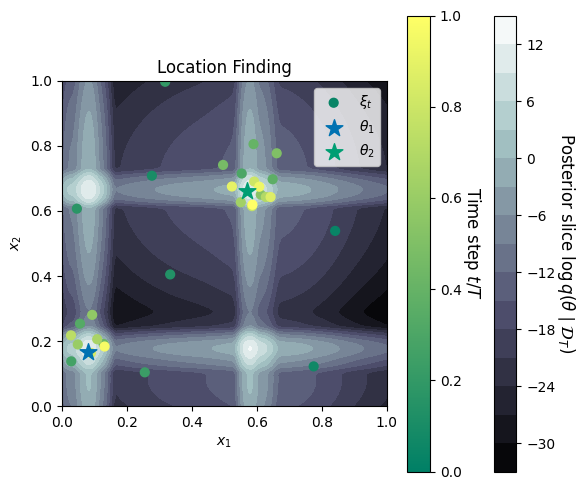

In [52]:
out = plot_policy2d_two_sources(model, experiment, cfg, 30, title="Location Finding", N=2000)

Posterior Mean and Standard Error: 

In [53]:
import random
import torch


def mixture_posterior_mean(mixture_means, mixture_weights, normalize=True):
    """
    Compute posterior mean from ALINE mixture output.

    Expected shapes:
    - mixture_means:   [B, D_target, C]
    - mixture_weights: [B, D_target, C] or [B, C]

    Returns:
    - posterior_mean: [B, D_target]
    """
    if mixture_weights.dim() == 2:
        weights = mixture_weights[:, None, :]  # [B, 1, C]
    elif mixture_weights.dim() == 3:
        weights = mixture_weights              # [B, D_target, C]
    else:
        raise ValueError(f"Unexpected mixture_weights shape: {mixture_weights.shape}")

    if normalize:
        weights = weights / (weights.sum(dim=-1, keepdim=True) + 1e-12)

    return (weights * mixture_means).sum(dim=-1)


def mse_perm_invariant_k2(theta_hat, theta_true, reduction="none"):
    """
    Permutation-invariant MSE for K=2 sources.

    theta_hat:  [B, 2, D]
    theta_true: [B, 2, D]

    Returns:
    - [B] if reduction="none"
    - scalar if reduction="mean"
    """
    assert theta_hat.shape == theta_true.shape
    assert theta_hat.shape[1] == 2

    mse_id = (
        ((theta_hat[:, 0] - theta_true[:, 0]) ** 2).sum(dim=-1)
        + ((theta_hat[:, 1] - theta_true[:, 1]) ** 2).sum(dim=-1)
    )

    mse_sw = (
        ((theta_hat[:, 0] - theta_true[:, 1]) ** 2).sum(dim=-1)
        + ((theta_hat[:, 1] - theta_true[:, 0]) ** 2).sum(dim=-1)
    )

    mse = torch.minimum(mse_id, mse_sw)

    # Mean over source index and coordinate dimension.
    mse = mse / (theta_hat.shape[1] * theta_hat.shape[2])

    if reduction == "none":
        return mse
    elif reduction == "mean":
        return mse.mean()
    else:
        raise ValueError(reduction)


@torch.no_grad()
def evaluate_policy_posterior_mean_mse(
    model,
    experiment,
    cfg,
    T=30,
    N=200,
    R=100,
    permutation_invariant=True,
    restore_n_query_init=True,
):
    """
    Evaluate posterior-mean MSE for an ALINE policy over R independent rollouts.

    Parameters
    ----------
    model:
        Trained ALINE model.

    experiment:
        ALINE-compatible experiment object with sample_batch and update_batch.

    cfg:
        Hydra config used by ALINE.

    T:
        Number of sequential queries / design steps.

    N:
        Number of candidate query locations per step.

    R:
        Number of independent rollouts for estimating mean and standard error.

    permutation_invariant:
        If True, use permutation-invariant MSE for K=2 sources.
        If False, use ordered MSE.

    restore_n_query_init:
        If True, restores experiment.n_query_init after evaluation.

    Returns
    -------
    dict with:
        - mse_mean
        - mse_se
        - mse_values
        - posterior_mean_theta
        - theta
    """
    model.eval()

    old_n_query_init = getattr(experiment, "n_query_init", None)
    experiment.n_query_init = N

    mse_values = []
    posterior_means = []
    true_thetas = []

    K = getattr(experiment, "K", 2)
    dim_x = getattr(experiment, "dim_x", 2)

    assert K == 2, f"Expected K=2 sources, got K={K}"
    assert dim_x == 2, f"Expected dim_x=2, got dim_x={dim_x}"

    for _ in range(R):
        batch = experiment.sample_batch(1)

        mask_type = random.choice(cfg.task.mask_type)

        batch.target_mask = create_target_mask(
            mask_type,
            cfg.task.embedding_type,
            cfg.task.n_target_data,
            cfg.task.n_target_theta,
            cfg.task.n_selected_targets,
            cfg.task.predefined_masks,
            cfg.task.predefined_mask_weights,
            cfg.task.mask_index,
            cfg.task.attend_to,
        )

        pred = None

        for _t in range(T):
            pred = model.forward(batch)
            idx = pred.design_out.idx
            batch = experiment.update_batch(batch, idx)

        if hasattr(batch, "target_theta"):
            theta_raw = batch.target_theta
        elif hasattr(batch, "theta"):
            theta_raw = batch.theta
        else:
            theta_raw = batch.target_all

        theta = theta_raw.reshape(theta_raw.shape[0], K, dim_x)

        posterior_mean_all = mixture_posterior_mean(
            pred.posterior_out.mixture_means,
            pred.posterior_out.mixture_weights,
        )

        if cfg.task.embedding_type == "mix":
            posterior_mean_theta_flat = posterior_mean_all[:, -cfg.task.n_target_theta:]
        else:
            posterior_mean_theta_flat = posterior_mean_all

        posterior_mean_theta = posterior_mean_theta_flat.reshape(
            theta.shape[0], K, dim_x
        )

        if permutation_invariant:
            mse = mse_perm_invariant_k2(
                posterior_mean_theta,
                theta,
                reduction="none",
            )  # [B]
        else:
            mse = ((posterior_mean_theta - theta) ** 2).mean(dim=(1, 2))  # [B]

        mse_values.append(mse.detach())
        posterior_means.append(posterior_mean_theta.detach())
        true_thetas.append(theta.detach())

    mse_values = torch.cat(mse_values, dim=0)  # [R]
    posterior_means = torch.cat(posterior_means, dim=0)  # [R, 2, 2]
    true_thetas = torch.cat(true_thetas, dim=0)  # [R, 2, 2]

    mse_mean = mse_values.mean()

    if mse_values.numel() > 1:
        mse_se = mse_values.std(unbiased=True) / torch.sqrt(
            torch.tensor(float(mse_values.numel()), device=mse_values.device)
        )
    else:
        mse_se = torch.zeros_like(mse_mean)

    if restore_n_query_init and old_n_query_init is not None:
        experiment.n_query_init = old_n_query_init

    return {
        "mse_mean": mse_mean,
        "mse_se": mse_se,
        "mse_values": mse_values,
        "posterior_mean_theta": posterior_means,
        "theta": true_thetas,
    }

In [55]:
res = evaluate_policy_posterior_mean_mse(
    model=model,
    experiment=experiment,
    cfg=cfg,
    T=30,
    N=200,
    R=100,
    permutation_invariant=True,
)

print(
    f"Posterior mean MSE: "
    f"{res['mse_mean'].item():.6f} ± {res['mse_se'].item():.6f}"
)

Posterior mean MSE: 0.041419 ± 0.003638


In [54]:
res = evaluate_policy_posterior_mean_mse(
    model=model,
    experiment=experiment,
    cfg=cfg,
    T=30,
    N=200,
    R=100,
    permutation_invariant=True,
)

print(
    f"Posterior mean MSE: "
    f"{res['mse_mean'].item():.6f} ± {res['mse_se'].item():.6f}"
)

Posterior mean MSE: 0.039035 ± 0.003298


## CES

### EIG Bounds

In [ ]:
cfg, experiment, model = load(["task=ces", f"task.n_query_init={n_query}"], "aline_ces.pth")

bounds = eval_boed(model, experiment, cfg.T-1, int(1e7), 2000, 10, cfg.time_token)

In [ ]:
@torch.no_grad()
def plot_posterior(model, experiment, T=30, N=200, title="CES"):
    # Evaluate model and generate data
    model.eval()
    experiment.n_query_init = N
    batch = experiment.sample_batch(1)
    theta = batch.target_theta.squeeze(-1)

    # Run T steps
    for t in range(T):
        pred = model.forward(batch)
        idx = pred.design_out.idx
        batch = experiment.update_batch(batch, idx)

    # Extract target variables
    rho = theta[..., 0]
    alpha = theta[..., 1:4]
    log_u = theta[..., 4]

    # Setup subplots
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    line_width = 2
    alpha_grid = 0.5

    # --- Plot rho ---
    ax = axes[0]
    x = torch.linspace(0, 1, 100).unsqueeze(-1)
    prob = compute_ll(x,
                      pred.posterior_out.mixture_means[:, 0],
                      pred.posterior_out.mixture_stds[:, 0],
                      pred.posterior_out.mixture_weights[:, 0]).exp()
    ax.plot(x.cpu().numpy(), prob.cpu().numpy(), linewidth=line_width)
    ax.axvline(rho.cpu().numpy(), color='#f55f51', linestyle='--')
    ax.set_title(r"$\rho$")
    ax.set_xlabel(r"$\rho$")
    # ax.set_ylabel(r"$p(\rho)$")
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%d'))
    ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.1f'))
    # Add minor ticks
    ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())
    # ax.grid(True, linestyle='--', alpha=alpha_grid)

    # --- Plot alpha ---
    ax = axes[1]
    x = torch.linspace(0, 1, 100).unsqueeze(-1)
    for i, a in enumerate(alpha.squeeze(0)):
        prob = compute_ll(x,
                          pred.posterior_out.mixture_means[:, i + 1],
                          pred.posterior_out.mixture_stds[:, i + 1],
                          pred.posterior_out.mixture_weights[:, i + 1]).exp()
        ax.plot(x.cpu().numpy(), prob.cpu().numpy(), linewidth=line_width)
        ax.axvline(a.cpu().numpy(), color='#f55f51', linestyle='--')
    ax.set_title(r"$\alpha$")
    ax.set_xlabel(r"$\alpha$")
    # ax.set_ylabel(r"$p(\alpha)$")
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%d'))
    ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.1f'))
    # Add minor ticks
    ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())
    # ax.grid(True, linestyle='--', alpha=alpha_grid)

    # --- Plot log(u) ---
    ax = axes[2]
    x = torch.linspace(-6, 8, 100).unsqueeze(-1)
    prob = compute_ll(x,
                      pred.posterior_out.mixture_means[:, 4],
                      pred.posterior_out.mixture_stds[:, 4],
                      pred.posterior_out.mixture_weights[:, 4]).exp()
    ax.plot(x.cpu().numpy(), prob.cpu().numpy(), linewidth=line_width)
    ax.axvline(log_u.cpu().numpy(), color='#f55f51', linestyle='--')
    ax.set_title(r"$u$")
    ax.set_xlabel(r"$\log(u)$")
    # ax.set_ylabel(r"$p(\log(u))$")
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%d'))
    ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.1f'))
    # Add minor ticks
    ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())
    # ax.grid(True, linestyle='--', alpha=alpha_grid)

    # Add ONE y-label for the whole figure
    fig.text(0.05, 0.5, r"$p(\theta)$", va='center', rotation='vertical', fontsize=14)

    # Final layout tweaks
    fig.suptitle(title, fontweight='bold')
    fig.tight_layout(rect=[0.05, 0, 1, 1])
    if not os.path.exists('../outputs/figures'):
        os.makedirs('../outputs/figures', exist_ok=True)
    plt.savefig('../outputs/figures/bed_pos_ces.pdf', bbox_inches='tight', dpi=300)
    plt.show()

In [ ]:
plot_posterior(model, experiment, T=10, N=n_query, title=None)

### **Simple Pendulum**